# A/B Testing — chiến dịch voucher

**Mục tiêu:** đo hiệu quả của voucher lên nhóm khách hàng mục tiêu (Cụm 2 — *Khách cuối tuần, trả Flex, tip thấp*)



#### Mục lục

| Phần | Nội dung |
|---|---|
| **1. Thiết kế Experiment** | |
| 1.1 Chọn đối tượng thí nghiệm | lọc rider cụm target · bốc thăm 50% mỗi khối |
| 1.2 Hypothesis & Metrics | H₀/H₁ · primary metric · **ngưỡng hoà vốn** (voucher + opex) |
| 1.3 Power Analysis | **MDE** từ SD *trong khối* · so với ngưỡng hoà vốn · kết luận đủ power hay không |
| **2. Kiểm tra Randomization** | |
| 2.1 Sample Ratio Mismatch | binomial test |
| 2.2 Covariate Balance | SMD 11 biến số + biến phân loại · Love plot · ngưỡng ±0.10 |
| **3. Ước lượng Tác động** | |
| 3.1 Ước lượng cơ bản | chênh lệch trung bình hai nhánh · SE Welch |
| 3.2 Ước lượng chính | `Y ~ T + block FE` · SE HC1  · phân phối hai nhánh |
| 3.3 Guardrail | doanh thu biên / rider · ATE theo hoạt động nền · voucher chi cho rider 0 chuyến  |
| **4. Monte Carlo Validation** | bốc lại `T` **1.000 lần** × 5 mức effect size · **bias** · **coverage 95%** · **power** (sai lầm loại I tại `s` = 0) |
| **5. Đánh giá Kinh doanh** | incremental trips · revenue · voucher cost · opex · net profit · **ROI** · **CPIT** · biên an toàn |
| **6. Rubric** | accuracy · bias · coverage · decision · cost · latency |
| **7. Phân tích CATE** | CATE từng cụm · ngưỡng hoà vốn riêng · rải cho tất cả vs rải có chọn lọc |
| **8. So sánh RCT vs Observational** | `propensity_true` · overlap · SMD có trọng số · naive vs **IPW/AIPW** vs RCT, đối chiếu `ate_true` |
| **9. Xuất Kết quả** | bảng summary · 9 file CSV |

## SET UP

In [1]:
# Nạp thư viện
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

# Khai báo đường dẫn dữ liệu
B    = r"c:/Users/Linh/Desktop/Growth & Experimentation Project for Ride-Hailing Promotions"
SRC  = os.path.join(B, "02. Synthetic_data", "output", "experiment_ab_final.csv")
SEG  = os.path.join(B, "03. Segmentation", "outputs", "rider_cluster.csv")
OUT  = os.path.join(B, "04. AB Testing", "output"); os.makedirs(OUT, exist_ok=True)

SEED = 42                      # dùng cho Monte Carlo ở mục 4

# Bảng màu dùng chung cho mọi biểu đồ trong notebook
SURFACE, INK, SECOND, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SERIES, ALT     = "#e1e0d9", "#c3c2b7", "#2a78d6", "#eb6834"


# Đọc dữ liệu thí nghiệm và nhãn phân cụm rồi ghép lại theo user_id
df  = pd.read_csv(SRC)
seg = pd.read_csv(SEG)[["user_id", "cluster", "persona", "is_target"]]

# validate="1:1" bắt buộc mỗi user_id chỉ xuất hiện một lần ở cả hai bảng.
# assert chặn thêm trường hợp merge làm mất dòng — sai ở đây thì mọi số phía sau đều sai.
_before = len(df)
df = df.merge(seg, on="user_id", how="inner", validate="1:1")
assert len(df) == _before, f"merge mất dòng: {_before:,} -> {len(df):,}"

## 1. Thiết kế Experiment

### 1.1 Chọn đối tượng thí nghiệm
Đơn vị là **rider**: mỗi người hoặc nhận voucher, hoặc không.

In [2]:
tg = df[df.is_target == 1].copy()

TARGET_CLUSTER = int(tg.cluster.iloc[0])
TARGET         = tg.persona.iloc[0]
t_, c_         = tg[tg.T_rct == 1], tg[tg.T_rct == 0]

assert tg.cluster.nunique() == 1, "nhom target trai tren nhieu cum — kiem tra buoc 03"

print(f"Cum {TARGET_CLUSTER} — {TARGET}")
print(f"   quy mo    : {len(tg):,} rider ({len(tg)/len(df):.1%})")
print(f"   treatment : {len(t_):,}")
print(f"   control   : {len(c_):,}")

Cum 2 — Khach cuoi tuan, tra Flex, tip thap
   quy mo    : 6,446 rider (32.2%)
   treatment : 3,216
   control   : 3,230


### 1.2 Hypothesis & Metrics

**Hypothesis**

| | |
|---|---|
| H₀ | Voucher không làm thay đổi số chuyến trung bình của rider thuộc cụm target |
| H₁ | Voucher làm tăng số chuyến trung bình |
| Primary metric | **Incremental Trips per Rider** — chênh lệch số chuyến/30 ngày giữa nhóm nhận và không nhận |
| Đơn vị ngẫu nhiên hoá | rider |

Cần một ngưỡng kinh tế — **ngưỡng hoà vốn**: mức tăng tối thiểu để chiến dịch không lỗ.
Giả sử: 
$$\text{BREAKEVEN} = \frac{\text{chi phí mỗi rider}}{\text{doanh thu biên mỗi chuyến}} = \frac{V + \text{opex}}{\overline{fare} \times \text{take rate}}$$

Chi phí mỗi rider gồm **mệnh giá voucher** và **chi phí vận hành** (gửi thông báo, hệ thống, nhân sự, hỗ trợ).

In [3]:
# Một rider phải tạo thêm bao nhiêu chuyến thì mới bù được chi phí chiến dịch.
# Ba tham số giả định
VOUCHER_VALUE  = 5.00     # USD mệnh giá voucher mỗi rider
OPEX_PER_RIDER = 1.25     # USD chi phí vận hành: gửi thông báo, hệ thống, nhân sự, hỗ trợ
TAKE_RATE      = 0.20     # tỷ lệ hoa hồng nền tảng giữ lại trên mỗi chuyến

# Tổng chi phí bỏ ra cho mỗi rider được gửi voucher
COST_PER_RIDER = VOUCHER_VALUE + OPEX_PER_RIDER


def breakeven(fare_mean):
    """Uplift tối thiểu để hoà vốn, tính bằng chuyến/rider.

    Mỗi chuyến tăng thêm mang về (cước trung bình x take rate) đồng doanh thu biên.
    Chia tổng chi phí cho con số đó ra số chuyến cần thêm để không lỗ.
    """
    return COST_PER_RIDER / (fare_mean * TAKE_RATE)


# Ngưỡng hoà vốn của riêng cụm target
BREAKEVEN = breakeven(tg.avg_fare.mean())

print(f"Mệnh giá voucher       : ${VOUCHER_VALUE:.2f} / rider")
print(f"Chi phí vận hành       : ${OPEX_PER_RIDER:.2f} / rider")
print(f"Tổng chi phí           : ${COST_PER_RIDER:.2f} / rider")
print(f"Cước TB cụm target     : ${tg.avg_fare.mean():.2f} / chuyến")
print(f"Doanh thu biên / chuyến: ${tg.avg_fare.mean() * TAKE_RATE:.2f}")
print(f"Ngưỡng hoà vốn         : {BREAKEVEN:.4f} chuyến / rider")

Mệnh giá voucher       : $5.00 / rider
Chi phí vận hành       : $1.25 / rider
Tổng chi phí           : $6.25 / rider
Cước TB cụm target     : $22.67 / chuyến
Doanh thu biên / chuyến: $4.53
Ngưỡng hoà vốn         : 1.3783 chuyến / rider


### 1.3 Power Analysis

**MDE** (Minimum Detectable Effect) là tác động nhỏ nhất mà thí nghiệm ở quy mô này còn phát hiện được với power 80%:

$$\text{MDE} = (z_{1-\alpha/2} + z_{\text{power}}) \times SE$$

Thí nghiệm chỉ **đủ sức** nếu `MDE < BREAKEVEN`.

In [4]:
ALPHA, POWER = 0.05, 0.80                    # mức ý nghĩa 5%, power mục tiêu 80%
z_a, z_b     = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(POWER)

# SE thiết kế phải khớp cách bốc thăm: T được bốc theo KHỐI, nên độ lệch chuẩn dùng ở đây là SD TRONG KHỐI của nhánh control
c0   = tg[tg.T_rct == 0]                     # chỉ lấy nhánh control để ước lượng SD(Y0)
_res = c0.Y_rct - c0.groupby("block_id").Y_rct.transform("mean")   

# Chia cho (n - số khối) vì đã dùng mất một bậc tự do cho mỗi khối
sd0     = float(np.sqrt((_res ** 2).sum() / (len(c0) - c0.block_id.nunique())))
sd0_tho = float(c0.Y_rct.std(ddof=1))        # SD thô, chỉ giữ để đối chiếu ở dòng print cuối

n1, n0 = len(t_), len(c_)                    # cỡ mẫu hai nhánh
se_d   = sd0 * np.sqrt(1 / n1 + 1 / n0)      # SE của hiệu hai trung bình
MDE    = (z_a + z_b) * se_d                  # tác động nhỏ nhất còn phát hiện được

# Thí nghiệm chỉ đủ sức nếu MDE nhỏ hơn ngưỡng hoà vốn — nếu không thì kể cả
# chiến dịch có lãi thật, thí nghiệm cũng không đủ nhạy để chứng minh.
mde_tab = pd.DataFrame([{
    "segment": TARGET, "n": len(tg), "treated": n1, "control": n0,
    "SD(Y0) trong khoi": sd0, "SE thiet ke": se_d,
    "MDE": MDE, "BREAKEVEN": BREAKEVEN,
    "MDE < BREAKEVEN?": "DU SUC" if MDE < BREAKEVEN else "THIEU LUC"}]).round(4)
display(mde_tab)

print(f"MDE {MDE:.4f} {'<' if MDE < BREAKEVEN else '>='} BREAKEVEN {BREAKEVEN:.4f}  ->  "
      f"thi nghiem {'DU SUC' if MDE < BREAKEVEN else 'THIEU LUC'} phat hien tac dong "
      f"o nguong hoa von.")
print(f"SD(Y0): trong khoi {sd0:.4f} vs tho {sd0_tho:.4f} — dung SD tho cho MDE "
      f"{(z_a + z_b) * sd0_tho * np.sqrt(1 / n1 + 1 / n0):.4f}, phinh "
      f"{sd0_tho / sd0 - 1:+.2%} vi tinh ca bien thien GIUA cac khoi ma thiet ke da khu.")

,segment,n,treated,control,SD(Y0) trong khoi,SE thiet ke,MDE,BREAKEVEN,MDE < BREAKEVEN?
0,"Khach cuoi tuan, tra Flex, tip thap",6446,3216,3230,5.5373,0.1379,0.3864,1.3783,DU SUC


MDE 0.3864 < BREAKEVEN 1.3783  ->  thi nghiem DU SUC phat hien tac dong o nguong hoa von.
SD(Y0): trong khoi 5.5373 vs tho 6.7534 — dung SD tho cho MDE 0.4713, phinh +21.96% vi tinh ca bien thien GIUA cac khoi ma thiet ke da khu.


## 2. Kiểm tra Randomization

### 2.1 Sample Ratio Mismatch (SRM)


In [5]:
from scipy.stats import binomtest

n_t, n_c = len(t_), len(c_)
srm = binomtest(n_t, n_t + n_c, 0.5)
print(f"Ty le chia nhom : {n_t:,} / {n_c:,}  ({n_t/(n_t+n_c):.1%} treatment)")
print(f"SRM binomial p  : {srm.pvalue:.4f}  ->  {'OK' if srm.pvalue > 0.001 else 'CO SRM - dung lai'}")

Ty le chia nhom : 3,216 / 3,230  (49.9% treatment)
SRM binomial p  : 0.8714  ->  OK


### 2.2 Covariate Balance

In [6]:
# Các covariate dùng để kiểm tra cân bằng
COV = ["total_rides", "recency_days", "typical_distance", "route_entropy",
       "pct_airport", "weekend_ratio", "pct_flex_payment", "pct_tip_rate",
       "avg_fare", "age", "is_urban"]

# Hàm tính Standardized Mean Difference (SMD)
# SMD = (mean_treatment - mean_control) / pooled_std
# |SMD| < 0.1: Hai nhóm được xem là cân bằng.
# |SMD| càng lớn: Hai nhóm càng khác nhau.
def smd(a, b):
    """Standardized Mean Difference — chenh lech chia do lech chuan gop."""
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return 0.0 if s == 0 else (a.mean() - b.mean()) / s

# Tính:
# - Giá trị trung bình của từng covariate trong Treatment
# - Giá trị trung bình trong Control
# - SMD giữa hai nhóm
bal = pd.DataFrame({
    "treatment": [t_[c].mean() for c in COV],
    "control":   [c_[c].mean() for c in COV],
    "SMD":       [smd(t_[c], c_[c]) for c in COV],
}, index=COV)

# Lấy trị tuyệt đối của SMD và sắp xếp theo mức mất cân bằng giảm dần.
bal["|SMD|"] = bal.SMD.abs()
bal = bal.sort_values("|SMD|", ascending=False)

# Hiển thị bảng kiểm tra cân bằng
display(bal.round(4))
print(f"|SMD| lon nhat = {bal['|SMD|'].max():.4f}  ->  "
      f"{'CAN BANG' if bal['|SMD|'].max() < 0.1 else 'MAT CAN BANG'}")

,treatment,control,SMD,|SMD|
typical_distance,2.9964,3.0529,-0.0306,0.0306
recency_days,14.7077,15.4294,-0.0302,0.0302
total_rides,21.7665,21.4464,0.0201,0.0201
route_entropy,2.7512,2.7355,0.0171,0.0171
avg_fare,22.6166,22.7275,-0.0157,0.0157
weekend_ratio,0.3805,0.3829,-0.0141,0.0141
age,41.2195,41.3641,-0.0104,0.0104
pct_flex_payment,0.4108,0.4096,0.0077,0.0077
pct_tip_rate,0.2160,0.2161,-0.0026,0.0026
is_urban,0.8411,0.8402,0.0023,0.0023


|SMD| lon nhat = 0.0306  ->  CAN BANG


In [7]:
# SMD cho biến PHÂN LOẠI: không tính trực tiếp được như biến số,
# nên tách từng mức thành biến 0/1 rồi tính SMD trên biến 0/1 đó.
CAT  = ["gender", "home_borough", "pref_time_bucket"]
rows = []

for col in CAT:
    for lev in sorted(tg[col].dropna().unique()):
        a = (t_[col] == lev).astype(float)      # 1 nếu rider treatment thuộc mức này
        b = (c_[col] == lev).astype(float)      # 1 nếu rider control thuộc mức này
        rows.append({"bien": f"{col} = {lev}", "treatment": a.mean(),
                     "control": b.mean(), "SMD": smd(a, b)})

# Sắp theo |SMD| giảm dần để mức lệch nhiều nhất nằm trên cùng
bal_cat = pd.DataFrame(rows)
bal_cat["|SMD|"] = bal_cat.SMD.abs()
bal_cat = bal_cat.sort_values("|SMD|", ascending=False).reset_index(drop=True)
display(bal_cat.round(4))

_m = bal_cat["|SMD|"].max()
print(f"|SMD| lon nhat tren bien phan loai = {_m:.4f}  ->  "
      f"{'CAN BANG' if _m < 0.1 else 'MAT CAN BANG'}")

,bien,treatment,control,SMD,|SMD|
0,home_borough = Brooklyn,0.0361,0.0477,-0.0580,0.0580
1,pref_time_bucket = evening,0.2565,0.2718,-0.0347,0.0347
2,home_borough = Queens,0.1191,0.1087,0.0328,0.0328
3,pref_time_bucket = morning,0.1720,0.1647,0.0194,0.0194
4,gender = Female,0.3333,0.3260,0.0156,0.0156
5,gender = Other,0.3433,0.3483,-0.0105,0.0105
6,pref_time_bucket = late_night,0.3455,0.3409,0.0097,0.0097
7,pref_time_bucket = midday,0.2261,0.2226,0.0083,0.0083
8,home_borough = Bronx,0.0037,0.0034,0.0055,0.0055
9,gender = Male,0.3234,0.3257,-0.0049,0.0049


|SMD| lon nhat tren bien phan loai = 0.0580  ->  CAN BANG


#### Visualize 

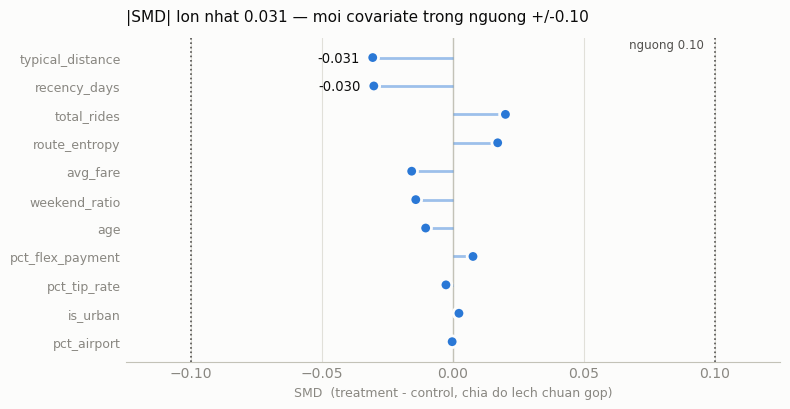

In [8]:
THR = 0.10

# Tạo figure hiển thị SMD của các covariate.
fig, ax = plt.subplots(figsize=(8, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Sắp xếp covariate theo |SMD| tăng dần để dễ quan sát.
o   = bal.sort_values("|SMD|")  

# Tọa độ Y của từng covariate.            
y   = np.arange(len(o))
col = [SERIES if v < THR else ALT for v in o["|SMD|"]]

# Vẽ đường tham chiếu:
# - x = 0: hai nhóm có trung bình bằng nhau.
# - ±THR: ngưỡng đánh giá cân bằng.
ax.axvline(0, color=AXIS, lw=1, zorder=1)
for x in (-THR, THR):
    ax.axvline(x, color=SECOND, lw=1.2, ls=":", zorder=1)
ax.text(THR - .004, len(o) - .55, f"nguong {THR:.2f}", color=SECOND,
        fontsize=8.5, va="center", ha="right")

# Vẽ lollipop chart:
# - Đường ngang biểu diễn giá trị SMD.
# - Điểm tròn đánh dấu vị trí SMD của từng covariate.
ax.hlines(y, 0, o.SMD, color=col, lw=2, alpha=.45)
ax.scatter(o.SMD, y, s=70, color=col, zorder=3,
           edgecolor=SURFACE, linewidth=2)

# Hiển thị giá trị SMD của hai covariate lệch nhiều nhất.
for i in (len(o) - 1, len(o) - 2):
    v = o.SMD.iloc[i]
    ax.text(v + (.005 if v >= 0 else -.005), i, f"{v:+.3f}", color=INK,
            fontsize=9.5, va="center", ha="left" if v >= 0 else "right")

# Định dạng biểu đồ:
# - Giới hạn trục.
# - Hiển thị tên covariate.
# - Thêm grid và tiêu đề.
ax.set_xlim(-THR * 1.25, THR * 1.25)
ax.set_ylim(-.7, len(o) - .3)
ax.set_yticks(y)
ax.set_yticklabels(o.index, fontsize=9, color=SECOND)
ax.set_xlabel("SMD  (treatment - control, chia do lech chuan gop)",
              fontsize=9, color=MUTED)
ax.xaxis.grid(True, color=GRID, lw=.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0)
_mx  = bal["|SMD|"].max()
_txt = "moi covariate trong nguong" if _mx < THR else "CO COVARIATE VUOT NGUONG"
ax.set_title(f"|SMD| lon nhat {_mx:.3f} — {_txt} +/-{THR:.2f}",
             fontsize=11, color=INK, loc="left", pad=12)
plt.tight_layout()
plt.show()

## 3. Ước lượng Tác động

### 3.1 Ước lượng cơ bản

Ước lượng của tác động voucher là **chênh lệch số chuyến trung bình** giữa hai nhánh:

$$\text{ATE}_{\text{}} = \bar{Y}_T - \bar{Y}_C$$

In [9]:
# Lấy outcome Y của 2 nhóm:
#   yT = số chuyến của rider nhận voucher (Treatment)
#   yC = số chuyến của rider không nhận voucher (Control)
yT = t_.Y_rct.to_numpy(float)
yC = c_.Y_rct.to_numpy(float)

# ATE cơ bản = trung bình Y nhánh treatment trừ trung bình Y nhánh control
ATE_BASIC = yT.mean() - yC.mean()

# STANDARD ERROR — WELCH
# Tính variance của sample mean ở mỗi nhóm:
# Treatment: s_T² / n_T
# Control  : s_C² / n_C
# ddof=1 → dùng sample variance.
_vT, _vC  = yT.var(ddof=1) / len(yT), yC.var(ddof=1) / len(yC)

# Standard Error của ATE: SE = sqrt(s_T²/n_T + s_C²/n_C)
SE_BASIC  = np.sqrt(_vT + _vC)
_df_b     = (_vT + _vC) ** 2 / (_vT ** 2 / (len(yT) - 1) + _vC ** 2 / (len(yC) - 1))
_q_b      = stats.t.ppf(1 - ALPHA / 2, _df_b)

# KHOẢNG TIN CẬY 95%: CI = ATE ± t_critical × SE
# LO_BASIC = cận dưới, HI_BASIC = cận trên
LO_BASIC, HI_BASIC = ATE_BASIC - _q_b * SE_BASIC, ATE_BASIC + _q_b * SE_BASIC

# P-VALUE
# Kiểm định
# H0: ATE = 0
# H1: ATE ≠ 0
# t = ATE / SE
PVAL_BASIC = 2 * stats.t.sf(abs(ATE_BASIC / SE_BASIC), _df_b)

# Lift tương đối so với Control:
# Lift = ATE / Mean(Control)
LIFT_BASIC = ATE_BASIC / yC.mean()

print(f"Y trung binh    : treatment {yT.mean():.4f} | control {yC.mean():.4f}")
print(f"ATE co ban      : {ATE_BASIC:+.4f} chuyen / 30 ngay   (hieu trung binh, SE Welch)")
print(f"SE              : {SE_BASIC:.4f}")
print(f"KTC 95%         : [{LO_BASIC:.4f}, {HI_BASIC:.4f}]")
print(f"Lift tuong doi  : {LIFT_BASIC:.1%}")
print(f"p-value         : {PVAL_BASIC:.4g}")
print(f"\nH0: {'BAC BO' if PVAL_BASIC < ALPHA else 'CHUA bac bo'}   |   "
      f"Vuot BREAKEVEN: {'CO' if LO_BASIC > BREAKEVEN else 'KHONG chac'}")

Y trung binh    : treatment 9.3999 | control 7.3201
ATE co ban      : +2.0798 chuyen / 30 ngay   (hieu trung binh, SE Welch)
SE              : 0.1709
KTC 95%         : [1.7448, 2.4147]
Lift tuong doi  : 28.4%
p-value         : 1.022e-33

H0: BAC BO   |   Vuot BREAKEVEN: CO


### 3.2 Ước lượng chính — `Y ~ T + block FE`
Nâng cấp ước lượng:
**Lý do không dùng thẳng hiệu trung bình ở 3.1?** Thiết kế bốc thăm 50% *trong từng khối*, mà các khối có mức `Y` nền khác nhau. Bỏ qua khối thì phần chênh **giữa** các khối nằm lại trong phần dư và làm sai số chuẩn phình lên — mục 1.3 đo được **+21.96%** (SD thô 6.7534 so với SD trong khối 5.5373).


In [ ]:
def ols_hc1(X, y, j=1):
    """Ước lượng hệ số OLS và sai số chuẩn HC1 cho biến thứ j.

    Mô hình:  Y ~ T `+ Block FE
        Y = số chuyến của rider trong 30 ngày
        T = treatment (1 = nhận voucher, 0 = control)
        Block FE = biến giả cho từng khối bốc thăm

    j = 1 vì cột thứ 1 của X là treatment T.

    Trả về:
        beta[j]      = hệ số của T, chính là uplift ước lượng
        sqrt(V[j,j]) = sai số chuẩn HC1 của uplift
    """
    XtX  = X.T @ X                       # ma trận X'X
    beta = np.linalg.solve(XtX, X.T @ y) # giải X'X·beta = X'y thay vì nghịch đảo ma trận
    r    = y - X @ beta                  # phần dư

    nn, k = X.shape                      # nn = số quan sát, k = số tham số

    # HC1 nới sai số chuẩn khi phương sai phần dư không đồng đều giữa các quan sát.
    # meat là phần giữa của công thức sandwich, mỗi quan sát được cân bằng r bình phương.
    meat = (X * (r ** 2)[:, None]).T @ X
    A    = np.linalg.solve(XtX, meat)                    # tương đương (X'X)^-1 · meat
    V    = np.linalg.solve(XtX, A.T).T * nn / (nn - k)   # nhân hệ số hiệu chỉnh mẫu nhỏ

    return beta[j], np.sqrt(V[j, j])


# Dựng ma trận thiết kế 
BLOCK_D = pd.get_dummies(tg.block_id, drop_first=True).to_numpy(float)
X_fe    = np.column_stack([np.ones(len(tg)), tg.T_rct.to_numpy(float), BLOCK_D])

# Ước lượng chính 
UPLIFT, SE = ols_hc1(X_fe, tg.Y_rct.to_numpy(float))

_dfree = len(tg) - X_fe.shape[1]              # bậc tự do còn lại sau khi trừ tham số
_q     = stats.t.ppf(1 - ALPHA / 2, _dfree)   # giá trị tới hạn t cho khoảng tin cậy 95%

LO, HI = UPLIFT - _q * SE, UPLIFT + _q * SE   # hai đầu khoảng tin cậy
PVAL   = 2 * stats.t.sf(abs(UPLIFT / SE), _dfree)   # kiểm định hai phía cho H0: uplift = 0
LIFT   = UPLIFT / c_.Y_rct.mean()          ;   # lift tương đối so với mức nền của control

print(f"Y trung binh    : treatment {t_.Y_rct.mean():.4f} | control {c_.Y_rct.mean():.4f}")
print(f"Uplift / rider  : {UPLIFT:+.4f} chuyen / 30 ngay   (Y ~ T + block FE, SE HC1)")
print(f"SE              : {SE:.4f}")
print(f"KTC 95%         : [{LO:.4f}, {HI:.4f}]")
print(f"Lift tuong doi  : {LIFT:.1%}")
print(f"p-value         : {PVAL:.4g}")
print(f"\nH0: {'BAC BO' if PVAL < ALPHA else 'CHUA bac bo'}   |   "
      f"Vuot BREAKEVEN: {'CO' if LO > BREAKEVEN else 'KHONG chac (KTC cham nguong hoa von)'}")

Y trung binh    : treatment 9.3999 | control 7.3201
Uplift / rider  : +1.9670 chuyen / 30 ngay   (Y ~ T + block FE, SE HC1)
SE              : 0.1412
KTC 95%         : [1.6901, 2.2439]
Lift tuong doi  : 26.9%
p-value         : 1.83e-43

H0: BAC BO   |   Vuot BREAKEVEN: CO


#### Visualize

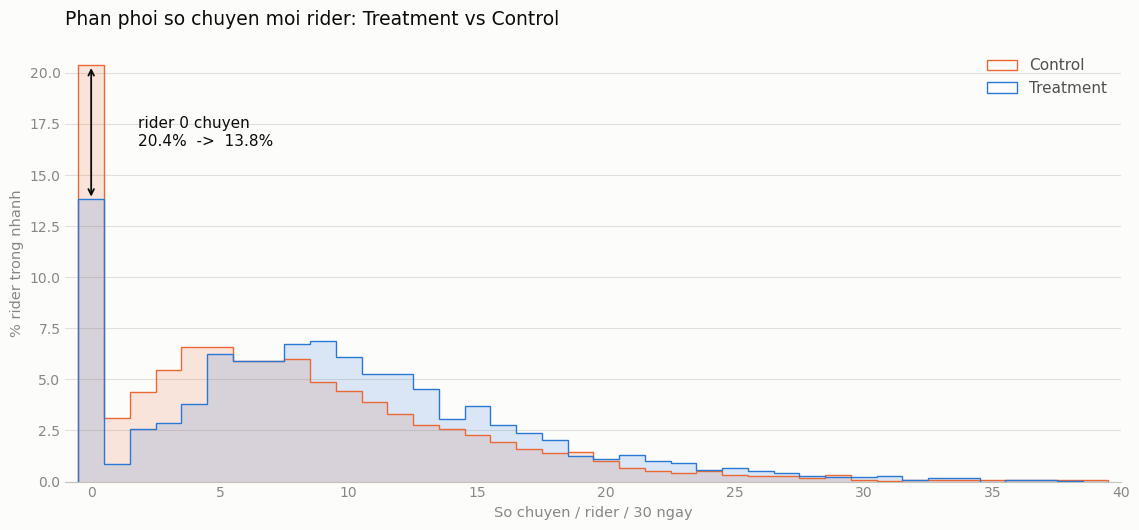

P(Y_treatment > Y_control) = 0.598
Trung vi : 6 -> 9 chuyen   |   Trung binh: 7.320 -> 9.400
Ty le rider 0 chuyen: 20.4% -> 13.8%  (giam 6.6 diem %)


In [11]:
# Biểu đồ tần suất cho thấy tác động đến từ đâu: voucher kéo bớt rider ra khỏi mốc 0 chuyến và đẩy cả phân phối sang phải.
fig, ax = plt.subplots(figsize=(11.5, 5.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bins = np.arange(-.5, 40.5, 1)
for _y, _col, _lab in ((yC, ALT, "Control"), (yT, SERIES, "Treatment")):
    # Đổi tần số sang phần trăm của từng nhánh vì hai nhánh không bằng nhau tuyệt đối
    _w = np.full(len(_y), 100 / len(_y))
    ax.hist(_y, bins=bins, weights=_w, color=_col, alpha=.16, zorder=2)      # phần tô nhạt
    ax.hist(_y, bins=bins, weights=_w, color=_col, histtype="step", lw=2.2,
            zorder=3, label=_lab)                                            # đường viền

# Mũi tên nối hai cột đầu tiên: chênh lệch tỷ lệ rider không đi chuyến nào
P0_C, P0_T = (yC == 0).mean() * 100, (yT == 0).mean() * 100
ax.annotate("", xy=(0, P0_T), xytext=(0, P0_C), zorder=5,
            arrowprops=dict(arrowstyle="<->", color=INK, lw=1.3))
ax.text(1.8, (P0_C + P0_T) / 2, f"rider 0 chuyen\n{P0_C:.1f}%  ->  {P0_T:.1f}%",
        color=INK, fontsize=11, va="center")

ax.legend(frameon=False, fontsize=11, labelcolor=SECOND, loc="upper right")
ax.set_xlim(-1, 40)
ax.set_xlabel("So chuyen / rider / 30 ngay", fontsize=10.5, color=MUTED)
ax.set_ylabel("% rider trong nhanh", fontsize=10.5, color=MUTED)
ax.grid(True, axis="y", color=GRID, lw=.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=10)
ax.set_title("Phan phoi so chuyen moi rider: Treatment vs Control",
             fontsize=13.5, color=INK, loc="left", pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "phanphoi_treatment_control.png"), dpi=160, facecolor=SURFACE)
plt.show()

# Ba con số tóm tắt phân phối, đọc kèm biểu đồ
MED_C, MED_T = np.median(yC), np.median(yT)

_U = stats.mannwhitneyu(yT, yC).statistic
print(f"P(Y_treatment > Y_control) = {_U / (len(yT) * len(yC)):.3f}")
print(f"Trung vi : {MED_C:.0f} -> {MED_T:.0f} chuyen   |   Trung binh: "
      f"{yC.mean():.3f} -> {yT.mean():.3f}")
print(f"Ty le rider 0 chuyen: {P0_C:.1f}% -> {P0_T:.1f}%  "
      f"(giam {P0_C - P0_T:.1f} diem %)")

### 3.3 Guardrail

| Guardrail | Rủi ro nó bắt |
|---|---|
| Doanh thu biên / rider | uplift dồn vào rider cước thấp → quy ra tiền bị thổi phồng |
| ATE theo mức hoạt động nền | một phân khúc bị hại dù trung bình vẫn dương |
| Voucher chi cho rider 0 chuyến | tiền rơi vào người không dùng tới |

In [12]:
GR_WASTE_MAX = 0.20            # tối đa % voucher rơi vào rider không đi chuyến nào


def _ate_in(d):
    """ATE và sai số chuẩn HC1 bên trong một nhóm con, vẫn giữ block FE."""
    D = pd.get_dummies(d.block_id, drop_first=True).to_numpy(float)
    return ols_hc1(np.column_stack([np.ones(len(d)), d.T_rct.to_numpy(float), D]),
                   d.Y_rct.to_numpy(float))


# G1 — DOANH THU BIÊN. Mục 1.3 quy uplift ra tiền bằng cước TRUNG BÌNH cả cụm. Giả
# định đó hỏng nếu chuyến tăng thêm dồn vào rider cước thấp. Đo thẳng trên doanh thu
# biên của từng rider rồi so với chi phí, không mượn cước trung bình nữa.
_rev       = tg.Y_rct.to_numpy(float) * tg.avg_fare.to_numpy(float) * TAKE_RATE
_g1, _s1   = ols_hc1(X_fe, _rev)
_g1_lo     = _g1 - _q * _s1                            # kịch bản xấu của doanh thu
_g1_assume = UPLIFT * tg.avg_fare.mean() * TAKE_RATE   # điều mục 1.3 ngầm giả định

# G2 — KHÔNG NHÓM NÀO BỊ HẠI. Chia theo mức hoạt động TRƯỚC thí nghiệm
_zg = stats.norm.ppf(1 - ALPHA / 2)
tg["hoat_dong_nen"] = pd.qcut(tg.total_rides, 3, labels=["thap", "trung", "cao"])
_seg = [(str(g), *_ate_in(d), len(d)) for g, d in tg.groupby("hoat_dong_nen", observed=True)]
_g2_hi_min = min(u + _zg * s for _, u, s, _n in _seg)  # cận trên xấu nhất qua ba nhóm

# G3 — LÃNG PHÍ. Chi phí tính trên MỖI rider được gửi voucher, kể cả người không
# phát sinh chuyến nào — phần đó là tiền chắc chắn mất.
_g3 = float((tg.loc[tg.T_rct == 1, "Y_rct"] == 0).mean())

guardrails = pd.DataFrame([
    {"guardrail": "Doanh thu bien tang them / rider",
     "do duoc": f"${_g1:.2f}  (KTC thap ${_g1_lo:.2f})",
     "nguong": f">= chi phi ${COST_PER_RIDER:.2f}",
     "ket qua": "DAT" if _g1_lo >= COST_PER_RIDER else "CANH BAO"},
    {"guardrail": "ATE moi nhom hoat dong nen",
     "do duoc": f"can tren xau nhat {_g2_hi_min:.4f}",
     "nguong": "> 0 o ca ba nhom",
     "ket qua": "DAT" if _g2_hi_min > 0 else "CANH BAO"},
    {"guardrail": "Voucher chi cho rider 0 chuyen",
     "do duoc": f"{_g3:.2%}",
     "nguong": f"<= {GR_WASTE_MAX:.0%}",
     "ket qua": "DAT" if _g3 <= GR_WASTE_MAX else "CANH BAO"},
])
display(guardrails)

,guardrail,do duoc,nguong,ket qua
0,Doanh thu bien tang them / rider,$8.49 (KTC thap $7.04),>= chi phi $6.25,DAT
1,ATE moi nhom hoat dong nen,can tren xau nhat 2.1589,> 0 o ca ba nhom,DAT
2,Voucher chi cho rider 0 chuyen,13.81%,<= 20%,DAT


## 4. Monte Carlo Validation

**Cách làm:** giữ nguyên `Y₀`/`Y₁`, chỉ **bốc lại `T`** 1.000 lần theo đúng thiết kế gốc (50% mỗi khối). Lặp ở 5 mức effect size `s`

| Báo cáo | Ý nghĩa | 
|---|---|
| **bias** | TB ước lượng − tác động thật |
| **coverage** | % lần KTC 95% phủ tác động thật | 
| **power** | % lần KTC 95% không chứa 0 |

In [13]:
# Tái lập hai potential outcome từ dữ liệu synthetic
Y0    = (tg.Y_rct - tg.ite_realized * tg.T_rct).to_numpy(float)
TAU_I = tg.ite_realized.to_numpy(float)        # tác động thật của từng rider

ate_true     = float(tg.cate_true.mean())      # estimand cấu trúc của mô hình sinh dữ liệu
ate_realized = float(TAU_I.mean())            

print(f"ate_true     = {ate_true:.4f} chuyen / rider")
print(f"ate_realized = {ate_realized:.4f} chuyen / rider   <- estimand cua nhanh RCT\n")

# Danh sách chỉ số của từng khối, dùng để bốc lại T đúng như thiết kế gốc
n_tg   = len(tg)
blocks = list(tg.reset_index(drop=True).groupby("block_id").indices.values())


def draw_T(rng):
    """Bốc lại treatment: đúng 50% mỗi khối, giống hệt cách chia nhóm ban đầu."""
    T = np.zeros(n_tg)
    for ix in blocks:
        T[rng.choice(ix, int(round(len(ix) * 0.5)), replace=False)] = 1.0
    return T


R      = 1000                              # số lần mô phỏng cho mỗi mức effect size
SCALES = [0.0, 0.10, 0.25, 0.50, 1.00]     # nhân tác động thật với từng hệ số này
z      = stats.norm.ppf(1 - ALPHA / 2)
rng    = np.random.default_rng(SEED)

# Dùng lại BLOCK_D của mục 3.
X = np.column_stack([np.ones(n_tg), np.zeros(n_tg), BLOCK_D])

recs = []
for s in SCALES:
    truth   = s * ate_realized             # tác động thật ở mức s này
    est, se = np.empty(R), np.empty(R)
    for r in range(R):
        T = draw_T(rng)                    # bốc lại nhóm
        Y = Y0 + s * TAU_I * T             # dựng lại outcome: Y1 = Y0 + s × tác động
        X[:, 1] = T
        est[r], se[r] = ols_hc1(X, Y)      # đo bằng đúng estimator của mục 3

    lo, hi = est - z * se, est + z * se    # khoảng tin cậy của từng lần mô phỏng
    recs.append({"he so s": s, "tac dong that": truth, "TB uoc luong": est.mean(),
                 # bias: ước lượng có lệch khỏi sự thật một cách hệ thống không
                 "bias": est.mean() - truth,
                 # coverage: bao nhiêu % khoảng tin cậy thật sự phủ được sự thật
                 "coverage": ((lo <= truth) & (truth <= hi)).mean(),
                 # power: bao nhiêu % lần phát hiện được tác động khác 0
                 "power": ((lo > 0) | (hi < 0)).mean()})

mc = pd.DataFrame(recs)
display(mc.round(4))
print(f"{len(SCALES)} muc effect size x {R:,} lan boc lai T = {len(SCALES) * R:,} thi nghiem mo phong")

ate_true     = 1.8368 chuyen / rider
ate_realized = 1.8332 chuyen / rider   <- estimand cua nhanh RCT



,he so s,tac dong that,TB uoc luong,bias,coverage,power
0,0.00,0.0000,0.0018,0.0018,0.951,0.049
1,0.10,0.1833,0.1768,-0.0065,0.950,0.249
2,0.25,0.4583,0.4608,0.0025,0.946,0.920
3,0.50,0.9166,0.9140,-0.0026,0.950,1.000
4,1.00,1.8332,1.8326,-0.0006,0.958,1.000


5 muc effect size x 1,000 lan boc lai T = 5,000 thi nghiem mo phong


In [14]:
_p_cov   = 1 - ALPHA                                 # 0.95 — coverage
_mc_cov  = np.sqrt(_p_cov * (1 - _p_cov) / R)        # SE của coverage
_mc_a    = np.sqrt(ALPHA * (1 - ALPHA) / R)          # SE của sai lầm loại I (= _mc_cov)

# Bias là TRUNG BÌNH của R ước lượng, không phải tỷ lệ, nên SE = SD/sqrt(R) với SD = se_d
_tol_b   = 1.96 * se_d / np.sqrt(R)

# Dải chấp nhận = giá trị đúng ± 1.96 SE
_lo_c, _hi_c = _p_cov - 1.96 * _mc_cov, _p_cov + 1.96 * _mc_cov   
_lo_a, _hi_a = ALPHA - 1.96 * _mc_a,    ALPHA + 1.96 * _mc_a      

_b_max = mc.bias.abs().max()                                           # bias lớn nhất
_n_in  = int(((mc.coverage >= _lo_c) & (mc.coverage <= _hi_c)).sum())  # số mức s đạt
_t1    = float(mc.loc[mc["he so s"] == 0, "power"].iloc[0])            # s = 0: dương tính giả

print(f"Bias     : lon nhat {_b_max:.4f}, nguong nhieu Monte Carlo {_tol_b:.4f}  ->  "
      f"{'KHONG THIEN VI' if _b_max <= _tol_b else 'CO DAU HIEU LECH'}")
print(f"Coverage : [{mc.coverage.min():.3f}, {mc.coverage.max():.3f}], dai Monte Carlo 95% quanh "
      f"{_p_cov:.2f} la [{_lo_c:.3f}, {_hi_c:.3f}]  ->  {_n_in}/{len(mc)} muc nam trong dai")
print(f"Sai lam loai I (s = 0): {_t1:.3f}, dai Monte Carlo 95% quanh {ALPHA:.2f} la "
      f"[{_lo_a:.3f}, {_hi_a:.3f}]  ->  {'DAT' if _lo_a <= _t1 <= _hi_a else 'LECH'}")

# Mức tác động thấp nhất đã đủ sức phát hiện — đối chiếu với MDE tính ở mục 1.3
_ok = mc[(mc["he so s"] > 0) & (mc.power >= POWER)]
if len(_ok):
    print(f"Power >= {POWER:.0%} tu tac dong {_ok['tac dong that'].iloc[0]:.4f} chuyen/rider "
          f"(MDE giai tich o muc 1.3: {MDE:.4f})")
else:
    print(f"Khong muc tac dong duong nao dat power {POWER:.0%} — thi nghiem thieu luc.")

Bias     : lon nhat 0.0065, nguong nhieu Monte Carlo 0.0085  ->  KHONG THIEN VI
Coverage : [0.946, 0.958], dai Monte Carlo 95% quanh 0.95 la [0.936, 0.964]  ->  5/5 muc nam trong dai
Sai lam loai I (s = 0): 0.049, dai Monte Carlo 95% quanh 0.05 la [0.036, 0.064]  ->  DAT
Power >= 80% tu tac dong 0.4583 chuyen/rider (MDE giai tich o muc 1.3: 0.3864)


## 5. Đánh giá Kinh doanh

| Câu hỏi | Căn cứ |
|---|---|
| Có **tác động** không? | p-value và KTC ở mục 3 |
| Đủ **hoà vốn** không? | cận dưới KTC so với `BREAKEVEN` |
| Ước lượng có **đáng tin** không? | bias và coverage ở mục 4 |

In [15]:
N_ROLLOUT = len(tg)                              # số rider sẽ được gửi voucher
MARGIN    = tg.avg_fare.mean() * TAKE_RATE       # doanh thu biên thu về trên mỗi chuyến

# Chi phí mỗi rider và ngưỡng hoà vốn đều lấy từ mục 1.2
INC_TRIPS   = UPLIFT * N_ROLLOUT                 # tổng số chuyến tăng thêm
COST        = COST_PER_RIDER * N_ROLLOUT         # tổng chi phí chiến dịch
INC_REVENUE = INC_TRIPS * MARGIN                 # doanh thu biên tăng thêm
NET         = INC_REVENUE - COST                 # lợi nhuận ròng
ROI         = NET / COST                         # tỷ lệ lãi trên vốn, không phụ thuộc quy mô
CPIT        = COST / INC_TRIPS                   # chi phí bỏ ra cho mỗi chuyến tăng thêm

econ = pd.DataFrame({
    "chi so": ["Rider duoc gui voucher", "Uplift dung de tinh", "Incremental trips",
               "Chi phi voucher", "Chi phi van hanh", "Tong chi phi",
               "Doanh thu bien tang them", "Loi nhuan rong", "ROI",
               "Chi phi / incremental trip", "Nguong hoa von"],
    "gia tri": [f"{N_ROLLOUT:,}", f"{UPLIFT:.4f} (diem uoc luong)", f"{INC_TRIPS:,.0f}",
                f"${VOUCHER_VALUE * N_ROLLOUT:,.0f}",
                f"${OPEX_PER_RIDER * N_ROLLOUT:,.0f}", f"${COST:,.0f}",
                f"${INC_REVENUE:,.0f}", f"${NET:,.0f}", f"{ROI:.1%}",
                f"${CPIT:.2f}", f"{BREAKEVEN:.4f} chuyen/rider"]})
display(econ)

,chi so,gia tri
0,Rider duoc gui voucher,"6,446"
1,Uplift dung de tinh,1.9670 (diem uoc luong)
2,Incremental trips,"12,679"
3,Chi phi voucher,"$32,230"
4,Chi phi van hanh,"$8,058"
5,Tong chi phi,"$40,288"
6,Doanh thu bien tang them,"$57,494"
7,Loi nhuan rong,"$17,206"
8,ROI,42.7%
9,Chi phi / incremental trip,$3.18


## 6. Rubric

| Trục | Đo bằng |
|---|---|
| **Accuracy** | \|uplift − `ate_realized`\| 
| **Bias** | \|TB ước lượng − sự thật\| qua 1.000 lần Monte Carlo | 
| **Coverage** | % lần KTC 95% phủ sự thật | 
| **Decision** | cận dưới KTC so với `BREAKEVEN` | 
| **Cost** | chi phí / incremental trip so với doanh thu biên | 
| **Latency** | thời gian một lần fit | 

In [16]:
import time

# Latency đo trên chính estimator của mục 3, lặp 50 lần rồi lấy trung bình
_y  = tg.Y_rct.to_numpy(float)
_t0 = time.perf_counter()
for _ in range(50):
    ols_hc1(X_fe, _y)
LATENCY_MS = (time.perf_counter() - _t0) / 50 * 1000

_mc1 = mc[mc["he so s"] == 1.0].iloc[0]        

# Ba chỉ số đầu đo chất lượng ước lượng, hai chỉ số sau đo giá trị kinh doanh
ACCURACY  = abs(UPLIFT - ate_realized)         # lệch bao nhiêu so với sự thật đã biết
BIAS_MAX  = float(mc.bias.abs().max())         # lệch hệ thống lớn nhất qua Monte Carlo
COV_LO, COV_HI = float(mc.coverage.min()), float(mc.coverage.max())

rubric = pd.DataFrame([
    ("Accuracy — |uplift - su that|", f"{ACCURACY:.4f}", "< 0.20",
     "PASS" if ACCURACY < 0.20 else "FAIL"),
    ("Bias — |TB uoc luong - su that| (MC)", f"{BIAS_MAX:.4f}", "< 0.05",
     "PASS" if BIAS_MAX < 0.05 else "FAIL"),
    ("Coverage — ty le KTC 95% phu su that", f"{COV_LO:.3f} - {COV_HI:.3f}", "0.93 - 0.97",
     "PASS" if (COV_LO >= 0.93 and COV_HI <= 0.97) else "FAIL"),
    ("Decision — can duoi KTC vuot BREAKEVEN", f"{LO:.4f} vs {BREAKEVEN:.4f}",
     "can duoi > BREAKEVEN", "PASS" if LO > BREAKEVEN else "FAIL"),
    ("Cost — chi phi / incremental trip", f"${CPIT:.2f}", f"< doanh thu bien ${MARGIN:.2f}",
     "PASS" if CPIT < MARGIN else "FAIL"),
    ("Latency — thoi gian mot lan fit", f"{LATENCY_MS:.2f} ms", "", "-"),
], columns=["tieu chi", "gia tri", "nguong", "ket qua"])
display(rubric)

_scored = rubric[rubric["ket qua"] != "-"]    

,tieu chi,gia tri,nguong,ket qua
0,Accuracy — |uplift - su that|,0.1338,< 0.20,PASS
1,Bias — |TB uoc luong - su that| (MC),0.0065,< 0.05,PASS
2,Coverage — ty le KTC 95% phu su that,0.946 - 0.958,0.93 - 0.97,PASS
3,Decision — can duoi KTC vuot BREAKEVEN,1.6901 vs 1.3783,can duoi > BREAKEVEN,PASS
4,Cost — chi phi / incremental trip,$3.18,< doanh thu bien $4.53,PASS
5,Latency — thoi gian mot lan fit,0.51 ms,,-


In [17]:
_sig   = PVAL < ALPHA
_prof  = LO > BREAKEVEN
_valid = (mc.bias.abs().max() < 0.05) and (0.93 <= mc.coverage.min() <= mc.coverage.max() <= 0.97)

print("KET LUAN")
print(f"1. Co tac dong?     uplift {UPLIFT:+.4f} chuyen/rider, p = {PVAL:.3g}"
      f"  ->  {'CO' if _sig else 'KHONG'}")
print(f"2. Du hoa von?      can duoi KTC {LO:.4f} vs BREAKEVEN {BREAKEVEN:.4f}"
      f"  ->  {'CO' if _prof else 'KHONG CHAC'}")
print(f"3. Uoc luong tin?   bias {mc.bias.abs().max():.4f}, coverage "
      f"[{mc.coverage.min():.3f}, {mc.coverage.max():.3f}]"
      f"  ->  {'DAT' if _valid else 'CAN XEM LAI'}")

print(f"\n=> {'TRIEN KHAI' if (_sig and _prof and _valid) else 'CHUA TRIEN KHAI'} "
      f"cho {N_ROLLOUT:,} rider cum target.")
print(f"   Loi nhuan rong ${NET:,.0f} | ROI {ROI:.1%} | ${CPIT:.2f} moi chuyen tang them")

KET LUAN
1. Co tac dong?     uplift +1.9670 chuyen/rider, p = 1.83e-43  ->  CO
2. Du hoa von?      can duoi KTC 1.6901 vs BREAKEVEN 1.3783  ->  CO
3. Uoc luong tin?   bias 0.0065, coverage [0.946, 0.958]  ->  DAT

=> TRIEN KHAI cho 6,446 rider cum target.
   Loi nhuan rong $17,206 | ROI 42.7% | $3.18 moi chuyen tang them


## 7. Câu hỏi Nếu rải voucher cho TẤT CẢ?

Tuy nhiên câu hỏi đặt ra là: *điều gì xảy ra nếu rải voucher cho toàn bộ 20.000 khách?*

| | |
|---|---|
| **Mỗi cụm có ngưỡng hoà vốn RIÊNG** | `BREAKEVEN = (V + opex) / (cước TB × take rate)`. Cước trung bình từng cụm khác nhau nên ngưỡng khác nhau |

In [18]:
def fe_cluster(d):
    """ATE và sai số chuẩn HC1 bên trong một nhóm rider.

    Dùng đúng estimator của mục 3 (Y ~ T + block FE) nhưng chạy riêng trong
    từng cụm, thay vì gộp cả tệp. Kết quả là CATE của cụm đó.
    """
    # Y_rct: số chuyến trong 30 ngày, T_rct: treatment ( 1: nhận voucher)
    y = d.Y_rct.to_numpy(float)
    t = d.T_rct.to_numpy(float)
    D = pd.get_dummies(d.block_id, drop_first=True).to_numpy(float)
    return ols_hc1(np.column_stack([np.ones(len(d)), t, D]), y)


_z    = stats.norm.ppf(1 - ALPHA / 2)     # giá trị tới hạn cho khoảng tin cậy 95%
_rows = []

for k, d in df.groupby("cluster"):
    u, s = fe_cluster(d)                  # CATE và SE của cụm này
    fare = d.avg_fare.mean()              # cước trung bình riêng của cụm
    _rows.append({"cum": str(k), "persona": d.persona.iloc[0], "n": len(d),
                  "CATE": u, "SE": s, "KTC thap": u - _z * s, "KTC cao": u + _z * s,
                  "cuoc TB": fare,
                  # cước khác nhau nên ngưỡng hoà vốn từng cụm cũng khác nhau
                  "BREAKEVEN rieng": breakeven(fare),
                  # cate_true là ground truth
                  "tau THAT": d.cate_true.mean()})

cate = pd.DataFrame(_rows)

# Cùng quy tắc quyết định như mục 5, nhưng so với ngưỡng RIÊNG của từng cụm:
#   cả khoảng tin cậy nằm trên ngưỡng  -> triển khai
#   chỉ điểm ước lượng vượt ngưỡng     -> cân nhắc
#   điểm ước lượng dưới ngưỡng         -> dừng
cate["quyet dinh"] = np.where(cate["KTC thap"] > cate["BREAKEVEN rieng"], "TRIEN KHAI",
                     np.where(cate["CATE"] > cate["BREAKEVEN rieng"], "CAN NHAC", "DUNG"))
display(cate.round(4))

# ATE gộp trên cả tệp, chỉ để đối chiếu — nó không phải một "cụm"
ATE_ALL, SE_ALL = fe_cluster(df)
BE_ALL   = breakeven(df.avg_fare.mean())
DEC_ALL  = ("TRIEN KHAI" if ATE_ALL - _z * SE_ALL > BE_ALL
            else "CAN NHAC" if ATE_ALL > BE_ALL else "DUNG")
_n_ship  = int((cate["quyet dinh"] == "TRIEN KHAI").sum())

print(f"ATE gop toan tep: {ATE_ALL:.4f} vs BREAKEVEN gop {BE_ALL:.4f}  ->  {DEC_ALL}")
print(f"Nhung chi {_n_ship}/{len(cate)} cum vuot duoc nguong hoa von RIENG cua no.\n")
for _, r in cate.iterrows():
    print(f"  cum {r['cum']}: cuoc ${r['cuoc TB']:>5.2f} -> breakeven "
          f"{r['BREAKEVEN rieng']:.4f} | CATE {r['CATE']:+.4f} "
          f"(tau {r['tau THAT']:+.4f}) -> {r['quyet dinh']}")

,cum,persona,n,CATE,SE,KTC thap,KTC cao,cuoc TB,BREAKEVEN rieng,tau THAT,quyet dinh
0,0,"Khach noi do ngay thuong, tip cao",10946,1.6016,0.1057,1.3944,1.8087,16.5076,1.8931,1.6001,DUNG
1,1,Khach san bay / duong dai,2608,0.4073,0.2895,-0.1602,0.9747,38.2606,0.8168,0.3879,DUNG
2,2,"Khach cuoi tuan, tra Flex, tip thap",6446,1.9670,0.1412,1.6902,2.2438,22.6722,1.3783,1.8368,TRIEN KHAI


ATE gop toan tep: 1.5668 vs BREAKEVEN gop 1.4650  ->  CAN NHAC
Nhung chi 1/3 cum vuot duoc nguong hoa von RIENG cua no.

  cum 0: cuoc $16.51 -> breakeven 1.8931 | CATE +1.6016 (tau +1.6001) -> DUNG
  cum 1: cuoc $38.26 -> breakeven 0.8168 | CATE +0.4073 (tau +0.3879) -> DUNG
  cum 2: cuoc $22.67 -> breakeven 1.3783 | CATE +1.9670 (tau +1.8368) -> TRIEN KHAI


In [19]:
# Quy đổi CATE từng cụm ra tiền để so hai kịch bản triển khai.
_c = cate.copy()
_c["chi phi"]         = COST_PER_RIDER * _c["n"]                     # voucher + vận hành
_c["trips tang them"] = _c["CATE"] * _c["n"]                         # chuyến tăng thêm
_c["doanh thu bien"]  = _c["trips tang them"] * _c["cuoc TB"] * TAKE_RATE
_c["loi nhuan"]       = _c["doanh thu bien"] - _c["chi phi"]
_c["ROI"]             = _c["loi nhuan"] / _c["chi phi"]

# Định dạng lại thành chuỗi cho dễ đọc, giữ bản số gốc trong _c để tính tiếp
pnl = _c[["cum", "persona", "n", "chi phi", "trips tang them",
          "doanh thu bien", "loi nhuan", "ROI"]].copy()
for _col in ("chi phi", "doanh thu bien", "loi nhuan"):
    pnl[_col] = pnl[_col].map("${:,.0f}".format)
pnl["trips tang them"] = pnl["trips tang them"].map("{:,.0f}".format)
pnl["ROI"]             = pnl["ROI"].map("{:.1%}".format)
print("Lai/lo neu rai voucher cho TUNG cum:")
display(pnl)

# Kịch bản có chọn lọc chỉ gồm những cụm đạt ngưỡng ở cell trên
_sel = _c[_c["quyet dinh"] == "TRIEN KHAI"]
scen = pd.DataFrame([
    ("Rai cho TAT CA", len(df), _c["chi phi"].sum(), _c["doanh thu bien"].sum()),
    ("Chi cum dat nguong", int(_sel["n"].sum()),
     _sel["chi phi"].sum(), _sel["doanh thu bien"].sum()),
], columns=["kich ban", "so rider", "chi phi", "doanh thu bien"])
scen["loi nhuan"] = scen["doanh thu bien"] - scen["chi phi"]
scen["ROI"]       = scen["loi nhuan"] / scen["chi phi"]

_show = scen.copy()
for _col in ("chi phi", "doanh thu bien", "loi nhuan"):
    _show[_col] = _show[_col].map("${:,.0f}".format)
_show["so rider"] = _show["so rider"].map("{:,}".format)
_show["ROI"]      = _show["ROI"].map("{:.1%}".format)
print("\nSo sanh hai kich ban:")
display(_show)

_b, _t = scen.iloc[0], scen.iloc[1]
print(f"Rai cho tat ca ton gap {_b['chi phi'] / _t['chi phi']:.1f} lan chi phi "
      f"nhung loi nhuan chi bang {_b['loi nhuan'] / _t['loi nhuan']:.0%} kich ban co chon loc.")

# Chỉ ra cụ thể cụm nào đang lỗ và lỗ vì lý do gì
for _, r in _c[_c["loi nhuan"] < 0].iterrows():
    print(f"Cum {r['cum']} ({r['persona']}) LO ${-r['loi nhuan']:,.0f} — CATE "
          f"{r['CATE']:.4f} khong du bu nguong hoa von {r['BREAKEVEN rieng']:.4f}.")

print("\nLý do phai target thay vi rai deu — du dia chi phi van hanh:")
_lat = {}
for _, r in scen.iterrows():
    _rev_pr = r["doanh thu bien"] / r["so rider"]     # doanh thu biên trên mỗi rider
    _max_op = _rev_pr - VOUCHER_VALUE                 # phần còn lại sau khi trả voucher
    _lat[r["kich ban"]] = _max_op
    print(f"  {r['kich ban']:<20}: doanh thu bien ${_rev_pr:>5.3f}/rider "
          f"-> opex toi da ${_max_op:>5.3f}/rider")

# Tỷ số giữa hai dư địa chính là mức độ bền hơn của kịch bản có chọn lọc
_blanket, _target = _lat["Rai cho TAT CA"], _lat["Chi cum dat nguong"]
print(f"  Cum target chiu duoc gap {_target / _blanket:.1f} lan kich ban rai deu.")
print(f"  Opex dang gia su ${OPEX_PER_RIDER:.2f} -> rai deu "
      f"{'DA VUOT diem lat' if OPEX_PER_RIDER > _blanket else 'con duoi diem lat'} "
      f"${_blanket:.3f}, con cum target van cach nguong ${_target:.3f} rat xa.")
print("  => Rai dai tra chi hoa von duoc neu chi phi van hanh gan bang 0.")

Lai/lo neu rai voucher cho TUNG cum:


,cum,persona,n,chi phi,trips tang them,doanh thu bien,loi nhuan,ROI
0,0,"Khach noi do ngay thuong, tip cao",10946,"$68,412","17,531","$57,879","$-10,534",-15.4%
1,1,Khach san bay / duong dai,2608,"$16,300","1,062","$8,127","$-8,173",-50.1%
2,2,"Khach cuoi tuan, tra Flex, tip thap",6446,"$40,288","12,679","$57,494","$17,206",42.7%



So sanh hai kich ban:


,kich ban,so rider,chi phi,doanh thu bien,loi nhuan,ROI
0,Rai cho TAT CA,"20,000","$125,000","$123,500","$-1,500",-1.2%
1,Chi cum dat nguong,"6,446","$40,288","$57,494","$17,206",42.7%


Rai cho tat ca ton gap 3.1 lan chi phi nhung loi nhuan chi bang -9% kich ban co chon loc.
Cum 0 (Khach noi do ngay thuong, tip cao) LO $10,534 — CATE 1.6016 khong du bu nguong hoa von 1.8931.
Cum 1 (Khach san bay / duong dai) LO $8,173 — CATE 0.4073 khong du bu nguong hoa von 0.8168.

Lý do phai target thay vi rai deu — du dia chi phi van hanh:
  Rai cho TAT CA      : doanh thu bien $6.175/rider -> opex toi da $1.175/rider
  Chi cum dat nguong  : doanh thu bien $8.919/rider -> opex toi da $3.919/rider
  Cum target chiu duoc gap 3.3 lan kich ban rai deu.
  Opex dang gia su $1.25 -> rai deu DA VUOT diem lat $1.175, con cum target van cach nguong $3.919 rat xa.
  => Rai dai tra chi hoa von duoc neu chi phi van hanh gan bang 0.


## 8. So sánh RCT vs Observational

| Cột | Cơ chế gán | 
|---|---|
| `T_rct` · `Y_rct` | bốc thăm 50% mỗi khối | 
| `T_obs` · `Y_obs` |Phụ thuộc đặc điểm rider| 
### 8.1 Kiểm tra cơ chế gán — propensity · overlap · balance

,SMD tho,SMD trong so,|SMD| tho
route_entropy,0.5708,-0.0113,0.5708
total_rides,0.5689,-0.0009,0.5689
is_urban,0.4662,0.0483,0.4662
recency_days,-0.4032,0.0096,0.4032
weekend_ratio,-0.1752,0.0260,0.1752
pct_flex_payment,-0.1455,-0.0041,0.1455
pct_airport,-0.1346,-0.0497,0.1346
pct_tip_rate,-0.1056,-0.0421,0.1056
avg_fare,-0.0991,-0.0902,0.0991
typical_distance,-0.0861,-0.0390,0.0861


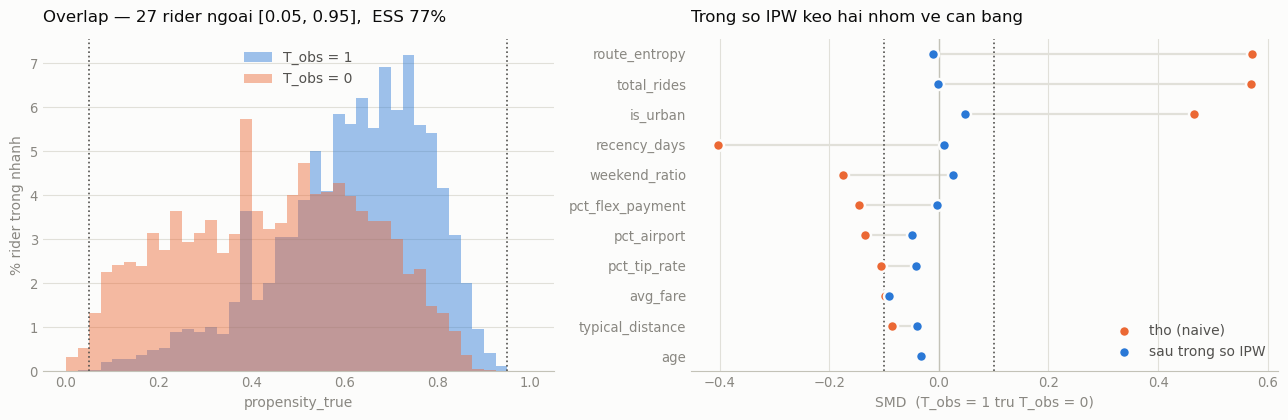

SMD tho     : lon nhat 0.5708  (8/11 bien vuot 0.10)
SMD trong so: lon nhat 0.0902  (0/11 bien vuot 0.10)
Overlap     : propensity trong [0.0072, 0.9468], 27 rider ngoai [0.05, 0.95], trong so lon nhat 28.9
ESS         : 4,945/6,446 rider (76.7%) — du de uoc luong


In [20]:
# Nhánh quan sát: T_obs KHÔNG bốc thăm mà do chọn, nên hai nhóm lệch nhau ngay
# từ đầu. propensity_true là xác suất nhận voucher THẬT của từng rider
PS_TRUE = tg.propensity_true.to_numpy(float)
PS_HAT  = smf.logit("T_obs ~ " + " + ".join(COV), data=tg).fit(disp=0).predict(tg).to_numpy()

_to = tg.T_obs.to_numpy(float)
# Trọng số IPW: mỗi rider đại diện cho 1/(xác suất vào đúng nhánh mà mình đang ở)
W = np.where(_to == 1, 1 / PS_TRUE, 1 / (1 - PS_TRUE))


def smd_w(a, b, wa, wb):
    """SMD có trọng số"""
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return 0.0 if s == 0 else (np.average(a, weights=wa) - np.average(b, weights=wb)) / s


_m1, _m0 = _to == 1, _to == 0
bal_obs = pd.DataFrame({
    "SMD tho":     [smd(tg[c][_m1], tg[c][_m0]) for c in COV],
    "SMD trong so": [smd_w(tg[c].to_numpy(float)[_m1], tg[c].to_numpy(float)[_m0],
                           W[_m1], W[_m0]) for c in COV]}, index=COV)
bal_obs["|SMD| tho"] = bal_obs["SMD tho"].abs()
bal_obs = bal_obs.sort_values("|SMD| tho", ascending=False)
display(bal_obs.round(4))

# Overlap: IPW chỉ đáng tin khi mọi rider đều CÓ THỂ rơi vào cả hai nhánh. 
ESS   = W.sum() ** 2 / (W ** 2).sum()                        # cỡ mẫu hiệu dụng
N_EXT = int(((PS_TRUE < .05) | (PS_TRUE > .95)).sum())       # rider ngoài vùng an toàn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.3), facecolor=SURFACE,
                               gridspec_kw={"width_ratios": [1, 1.15]})

# Panel 1 — phân phối propensity hai nhánh. Chồng lấn càng nhiều thì IPW càng vững.
for _msk, _col, _lab in ((_m1, SERIES, "T_obs = 1"), (_m0, ALT, "T_obs = 0")):
    ax1.hist(PS_TRUE[_msk], bins=np.linspace(0, 1, 41), color=_col, alpha=.45,
             weights=np.full(_msk.sum(), 100 / _msk.sum()), label=_lab)
for _x in (.05, .95):
    ax1.axvline(_x, color=SECOND, lw=1.2, ls=":")
ax1.set_title(f"Overlap — {N_EXT} rider ngoai [0.05, 0.95],  ESS {ESS / len(tg):.0%}",
              fontsize=12, color=INK, loc="left", pad=12)
ax1.set_xlabel("propensity_true", fontsize=10, color=MUTED)
ax1.set_ylabel("% rider trong nhanh", fontsize=10, color=MUTED)
ax1.legend(frameon=False, fontsize=10, labelcolor=SECOND)

# Panel 2 — Love plot: SMD trước và sau khi gán trọng số, cùng một trục
_o = bal_obs.sort_values("|SMD| tho")
_y = np.arange(len(_o))
ax2.axvline(0, color=AXIS, lw=1)
for _x in (-.10, .10):
    ax2.axvline(_x, color=SECOND, lw=1.2, ls=":")
ax2.hlines(_y, _o["SMD tho"], _o["SMD trong so"], color=GRID, lw=1.6, zorder=1)
ax2.scatter(_o["SMD tho"], _y, s=62, color=ALT, zorder=3, edgecolor=SURFACE,
            linewidth=1.8, label="tho (naive)")
ax2.scatter(_o["SMD trong so"], _y, s=62, color=SERIES, zorder=3, edgecolor=SURFACE,
            linewidth=1.8, label="sau trong so IPW")
ax2.set_yticks(_y); ax2.set_yticklabels(_o.index, fontsize=9, color=SECOND)
ax2.set_xlabel("SMD  (T_obs = 1 tru T_obs = 0)", fontsize=10, color=MUTED)
ax2.set_title("Trong so IPW keo hai nhom ve can bang", fontsize=12, color=INK,
              loc="left", pad=12)
ax2.legend(frameon=False, fontsize=10, labelcolor=SECOND, loc="lower right")

for _a in (ax1, ax2):
    _a.set_facecolor(SURFACE)
    _a.grid(True, axis="x" if _a is ax2 else "y", color=GRID, lw=.8)
    _a.set_axisbelow(True)
    for _s in ("top", "right", "left"):
        _a.spines[_s].set_visible(False)
    _a.spines["bottom"].set_color(AXIS)
    _a.tick_params(colors=MUTED, length=0, labelsize=9.5)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "obs_overlap_balance.png"), dpi=160, facecolor=SURFACE)
plt.show()

print(f"SMD tho     : lon nhat {bal_obs['SMD tho'].abs().max():.4f}  "
      f"({int((bal_obs['SMD tho'].abs() >= .10).sum())}/{len(COV)} bien vuot 0.10)")
print(f"SMD trong so: lon nhat {bal_obs['SMD trong so'].abs().max():.4f}  "
      f"({int((bal_obs['SMD trong so'].abs() >= .10).sum())}/{len(COV)} bien vuot 0.10)")
print(f"Overlap     : propensity trong [{PS_TRUE.min():.4f}, {PS_TRUE.max():.4f}], "
      f"{N_EXT} rider ngoai [0.05, 0.95], trong so lon nhat {W.max():.1f}")
print(f"ESS         : {ESS:,.0f}/{len(tg):,} rider ({ESS / len(tg):.1%}) — "
      f"{'du de uoc luong' if ESS / len(tg) >= .5 else 'qua thap, IPW khong dang tin'}")

### 8.2 Ước lượng — naive · IPW · AIPW

- **Naive** — so trung bình hai nhánh 
- **IPW (Hájek)** — cân lại mẫu bằng nghịch đảo xác suất, chuẩn hoá theo tổng trọng số. Đúng nếu **mô hình propensity** đúng.
- **AIPW** — ghép thêm mô hình outcome. Chỉ cần **một trong hai** mô hình đúng là vẫn nhất quán (*doubly robust*).

Mỗi estimator chạy hai lần: một lần với `propensity_true` (chỉ synthetic mới có), một lần với propensity **ước lượng** bằng logistic 

In [21]:
# Ba estimator trên CÙNG một dữ liệu quan sát, đối chiếu với ate_true đã biết.
_y  = tg.Y_obs.to_numpy(float)
_Xc = np.column_stack([np.ones(len(tg)), tg[COV].to_numpy(float)])


def ipw_hajek(y, t, e):
    """IPW chuẩn hoá. Chia cho tổng trọng số nên ổn định hơn Horvitz-Thompson.

    SE lấy từ hàm ảnh hưởng, coi trọng số là cho trước.
    """
    w1, w0 = t / e, (1 - t) / (1 - e)
    m1, m0 = (w1 @ y) / w1.sum(), (w0 @ y) / w0.sum()
    psi    = w1 * (y - m1) / w1.mean() - w0 * (y - m0) / w0.mean()
    return m1 - m0, psi.std(ddof=1) / np.sqrt(len(y))


def aipw(y, t, e, X):
    """AIPW (doubly robust): ghép mô hình outcome với trọng số propensity.

    Chỉ cần MỘT trong hai mô hình đúng là ước lượng vẫn nhất quán — đó là ý nghĩa
    của chữ "doubly robust". Phần trọng số ở đây chỉ hiệu chỉnh phần dư của mô hình
    outcome, nên nó chịu đựng trọng số lớn tốt hơn IPW thuần.
    """
    b1 = np.linalg.lstsq(X[t == 1], y[t == 1], rcond=None)[0]
    b0 = np.linalg.lstsq(X[t == 0], y[t == 0], rcond=None)[0]
    m1, m0 = X @ b1, X @ b0
    psi = m1 - m0 + t * (y - m1) / e - (1 - t) * (y - m0) / (1 - e)
    return psi.mean(), psi.std(ddof=1) / np.sqrt(len(y))


# Naive: so trung bình hai nhánh 
_nv    = _y[_m1].mean() - _y[_m0].mean()
_nv_se = np.sqrt(_y[_m1].var(ddof=1) / _m1.sum() + _y[_m0].var(ddof=1) / _m0.sum())

_rows = [("Naive (khong hieu chinh)", "T_obs", _nv, _nv_se)]
for _nm, _e in (("ps THAT", PS_TRUE), ("ps uoc luong", PS_HAT)):
    _rows.append((f"IPW Hajek", _nm, *ipw_hajek(_y, _to, _e)))
    _rows.append((f"AIPW (doubly robust)", _nm, *aipw(_y, _to, _e, _Xc)))
_rows.append(("RCT — block FE (muc 3.2)", "T_rct boc tham", UPLIFT, SE))

_zo = stats.norm.ppf(1 - ALPHA / 2)
obs_est = pd.DataFrame(_rows, columns=["estimator", "propensity", "uoc luong", "SE"])
obs_est["KTC thap"] = obs_est["uoc luong"] - _zo * obs_est.SE
obs_est["KTC cao"]  = obs_est["uoc luong"] + _zo * obs_est.SE
obs_est["lech vs truth"] = obs_est["uoc luong"] - ate_true
obs_est["phu truth"] = np.where((obs_est["KTC thap"] <= ate_true) &
                                (ate_true <= obs_est["KTC cao"]), "CO", "KHONG")
display(obs_est.round(4))

_bias_nv  = _nv - ate_true
_best_obs = obs_est.iloc[1:-1]["lech vs truth"].abs().max()
print(f"ate_true = {ate_true:.4f} chuyen / rider\n")
print(f"Naive lech {_bias_nv:+.4f} ({abs(_bias_nv) / ate_true:.0%} so voi su that) — "
      f"toan bo phan du la CONFOUNDING, khong phai tac dong cua voucher.")
print(f"Sau hieu chinh, sai lech lon nhat con {_best_obs:.4f} "
      f"({_best_obs / abs(_bias_nv):.0%} cua sai lech naive).")
print(f"{int((obs_est['phu truth'] == 'CO').sum())}/{len(obs_est)} estimator co KTC phu ate_true.")

,estimator,propensity,uoc luong,SE,KTC thap,KTC cao,lech vs truth,phu truth
0,Naive (khong hieu chinh),T_obs,4.8665,0.1639,4.5453,5.1877,3.0297,KHONG
1,IPW Hajek,ps THAT,2.0657,0.2043,1.6654,2.4661,0.2289,CO
2,AIPW (doubly robust),ps THAT,2.0171,0.1559,1.7115,2.3227,0.1803,CO
3,IPW Hajek,ps uoc luong,1.9964,0.2157,1.5735,2.4192,0.1596,CO
4,AIPW (doubly robust),ps uoc luong,2.0612,0.1607,1.7462,2.3763,0.2244,CO
5,RCT — block FE (muc 3.2),T_rct boc tham,1.9670,0.1412,1.6902,2.2438,0.1302,CO


ate_true = 1.8368 chuyen / rider

Naive lech +3.0297 (165% so voi su that) — toan bo phan du la CONFOUNDING, khong phai tac dong cua voucher.
Sau hieu chinh, sai lech lon nhat con 0.2289 (8% cua sai lech naive).
5/6 estimator co KTC phu ate_true.


## 9. Xuất Kết quả

In [22]:
_mc1 = mc[mc["he so s"] == 1.0].iloc[0]          

summary = pd.DataFrame({
    "chi so": ["cum target", "so rider", "uplift / rider", "SE", "KTC 95% thap",
               "KTC 95% cao", "lift tuong doi", "p-value", "MDE", "BREAKEVEN",
               "ate_true", "ate_realized (estimand RCT)", "bias (Monte Carlo)", "coverage (Monte Carlo)",
               "sai lam loai I (Monte Carlo)", "ROI", "chi phi / incremental trip"],
    "gia tri": [TARGET_CLUSTER, N_ROLLOUT, round(UPLIFT, 4), round(SE, 4), round(LO, 4),
                round(HI, 4), f"{LIFT:.1%}", f"{PVAL:.4g}", round(MDE, 4), round(BREAKEVEN, 4),
                round(ate_true, 4), round(ate_realized, 4),
                round(float(_mc1.bias), 4), round(float(_mc1.coverage), 4),
                round(float(mc.loc[mc["he so s"] == 0, "power"].iloc[0]), 4),
                f"{ROI:.1%}", f"${CPIT:.2f}"]})
display(summary)

# Xuất từng bảng ra CSV
_files = {"ab_summary.csv": summary, "power_analysis.csv": mde_tab,
          "montecarlo_validation.csv": mc.round(4), "economics.csv": econ,
          "balance_rct.csv": bal.round(4),
          "rubric_evaluation.csv": rubric,
          "guardrails.csv": guardrails,
          "obs_estimates.csv": obs_est.round(4),
          "obs_balance.csv": bal_obs.round(4)}
for fn, d in _files.items():
    # hai bảng balance giữ index vì index của chúng là tên covariate
    d.to_csv(os.path.join(OUT, fn), index=(fn in ("balance_rct.csv", "obs_balance.csv")))
    print(f"  {fn:<28} {os.path.getsize(os.path.join(OUT, fn)):>7,} bytes")

,chi so,gia tri
0,cum target,2
1,so rider,6446
2,uplift / rider,1.967
3,SE,0.1412
4,KTC 95% thap,1.6901
5,KTC 95% cao,2.2439
6,lift tuong doi,26.9%
7,p-value,1.83e-43
8,MDE,0.3864
9,BREAKEVEN,1.3783


  ab_summary.csv                   381 bytes
  power_analysis.csv               177 bytes
  montecarlo_validation.csv        239 bytes
  economics.csv                    342 bytes
  balance_rct.csv                  497 bytes
  rubric_evaluation.csv            417 bytes
  guardrails.csv                   237 bytes
  obs_estimates.csv                489 bytes
  obs_balance.csv                  423 bytes
